# libary

In [45]:
import pandas as pd

from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

## 12.5 С чего начинается: смотрим "на глазок"

In [2]:
d = pd.read_excel('./data/TSA.xlsx')

In [4]:
d.head()

,Дата,Продажи,Отгрузка
0,2018-01-01,74440,449
1,2018-02-01,73344,512
2,2018-03-01,72517,655
3,2018-04-01,74765,600
4,2018-05-01,78176,591


<Axes: xlabel='Дата'>

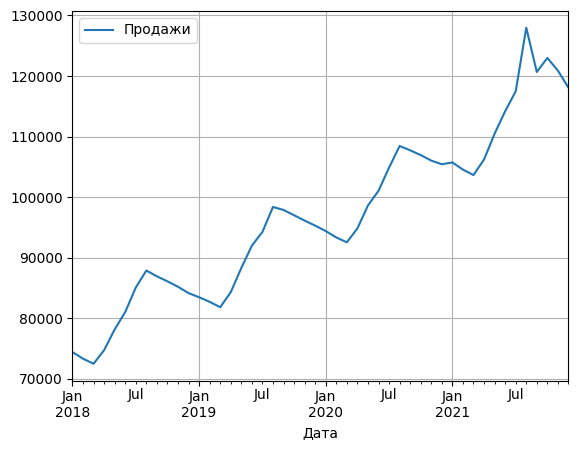

In [7]:
d.plot(x='Дата', y='Продажи', kind='line', grid=True)

## 12.6 Подавление "шумов":HPF(Hodrick-Prescott Filter) отделение тренда

In [11]:
# тут lamb параметр сглаживания, где для квартала ставим 1600, а для месяца 129600;
# если тренд слишком гладкий (не улавливает изменения), можно уменьшить lamb;
# а если тренд слишком повторяет исходный ряд увеличьте lamb.
cycle, trend = hpfilter(d['Продажи'], lamb=129600)

In [12]:
d['T'] = trend
d['C'] = cycle

<Axes: xlabel='Дата'>

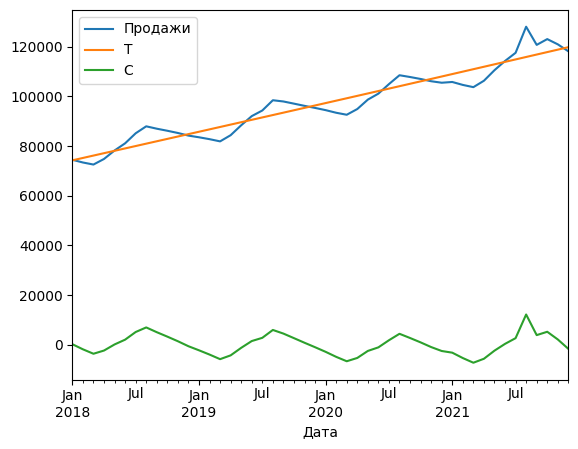

In [13]:
d.plot(x='Дата', y=['Продажи', 'T', 'C'])

In [15]:
stl = STL(d['Продажи'], period=12) # period=12 для месячных данных

In [16]:
r = stl.fit()

In [17]:
d['T2'] = r.trend
d['S'] = r.seasonal
d['Res'] = r.resid

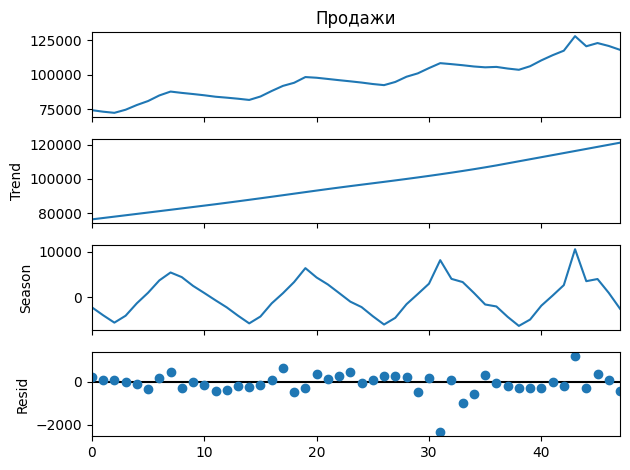

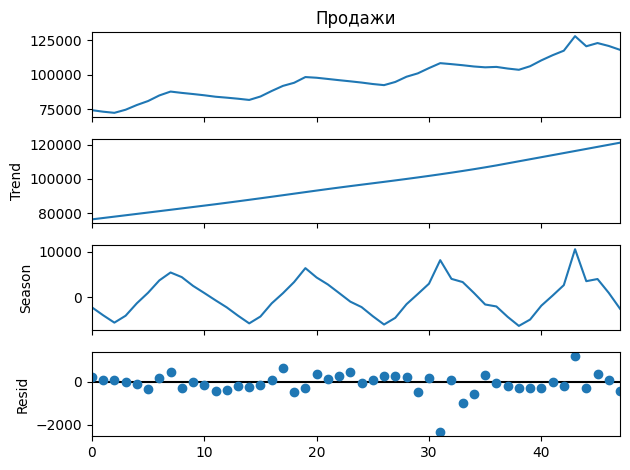

In [18]:
r.plot()

In [27]:
d.columns

Index(['Дата', 'Продажи', 'Отгрузка', 'T', 'C', 'T2', 'S', 'Res'], dtype='object')

<Axes: xlabel='Дата'>

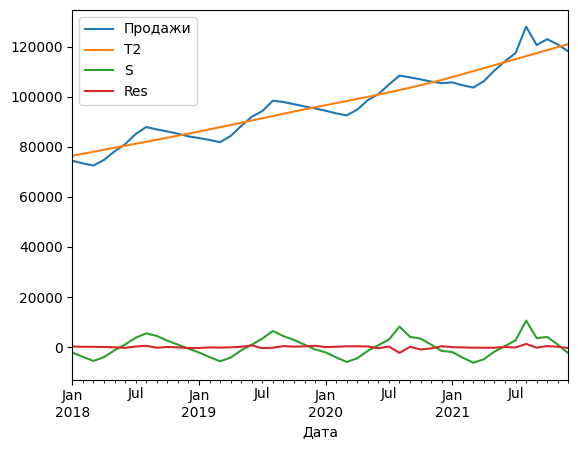

In [28]:
d.plot(x='Дата', y=['Продажи','T2', 'S', 'Res'])

Лаги \ lags – это разделы годов в месяцах (так как у нас данные помесячно: 12, 24, 36 - это расстояние между "одинаковыми" месяцами в разных годах декабрь каждого года будет 12, 24, 36 и август каждого года будет отставать от августа каждого следующего года на эти цифры, и любой другой месяц).

In [29]:
acorr_ljungbox(d['Продажи'], lags=[12, 24, 36], return_df=True)

,lb_stat,lb_pvalue
12,207.019243,1.157039e-37
24,223.743329,2.477482e-34
36,409.642157,6.715214e-65


## 12.8 (s)ARIMA(x): обучение на временном ряде и его прогнозирование

### дифференцирование

In [32]:
adfuller(d['Продажи']) #  смотрите на второе число, это р-значение если < 0.05 то тест стационарен. У Вас он будет явно НЕСТАЦИОНАРЕН. Р=0,99, почти 1.

(np.float64(1.7911255912098132),
 np.float64(0.9983312527202051),
 10,
 37,
 {'1%': np.float64(-3.6209175221605827),
  '5%': np.float64(-2.9435394610388332),
  '10%': np.float64(-2.6104002410518627)},
 np.float64(674.65058295109))

In [33]:
kpss(d['Продажи']) # если р > 0.05 то ряд стационарен - но у Вас будет менее: значит ряд таки точно нестационарен.

C:\Users\ilyao\AppData\Local\Temp\ipykernel_17716\1674457302.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss(d['Продажи']) # если р > 0.05 то ряд стационарен - но у Вас будет менее: значит ряд таки точно нестационарен.


(np.float64(1.006635114391043),
 np.float64(0.01),
 4,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [34]:
d['diff'] = d['Продажи'].diff()

In [36]:
adfuller(d['diff'].dropna())

(np.float64(-4.74329837031424),
 np.float64(6.972775007602819e-05),
 10,
 36,
 {'1%': np.float64(-3.626651907578875),
  '5%': np.float64(-2.9459512825788754),
  '10%': np.float64(-2.6116707716049383)},
 np.float64(659.5216858803512))

In [37]:
kpss(d['diff'].dropna())

C:\Users\ilyao\AppData\Local\Temp\ipykernel_17716\4117312546.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss(d['diff'].dropna())


(np.float64(0.03211798908848367),
 np.float64(0.1),
 3,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

### сезонное дифференцирование
Если у Вас есть сезонность (а она есть), то независимо от того стационарен ряд или нет - надо провести сезонное дифференцирование

In [38]:
d['diff'] = d['Продажи'].diff(12).diff()

In [39]:
adfuller(d['diff'].dropna())

(np.float64(-11.995868513937767),
 np.float64(3.435258328222089e-22),
 0,
 34,
 {'1%': np.float64(-3.639224104416853),
  '5%': np.float64(-2.9512301791166293),
  '10%': np.float64(-2.614446989619377)},
 np.float64(428.16233387053757))

In [40]:
kpss(d['diff'].dropna())

C:\Users\ilyao\AppData\Local\Temp\ipykernel_17716\4117312546.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss(d['diff'].dropna())


(np.float64(0.0623724008688783),
 np.float64(0.1),
 2,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

---
О количестве лагов:  у Вас данные за 4 года (48 мес\строк), было удалено 13 – осталось 35 строк. Т.е, макс лаг может быть только 35: ибо нельзя задать lags больше оставшегося числа точек. Но на практике лучше не превышать около 1\2 или 1\3 длины ряда. Т.е., для 35 точек ставим лаг 35\2=17,5 пусть будет 20. Причем если есть сезонность помесячно в году, то минимум 12 лагов должно быть указано (если бы мы на 3 поделили – то было бы 11, это не подошло бы в нашем случае надо было бы по любому не менее 12 ставить).

---

Рассмотрите на диаграмме ACF есть ли на 12 лаге всплеск - возможно, еще осталась сезонность. Если осталась - додифференцируйте .diff(12), помня что это надо сделать до дифференцирования ряда.

Далее проверьте находятся ли все лаги в пределах доверительного интервала - если да, то параметр q=0. Если нет, то посчитайте сколько у Вас лагов вне интервала - количество лагов вне интервала и будет параметром q.

Большое Q для сезонной компоненты посмотрите  по лагам сезонности - на месячной основе это 12, 24, 36… но у Вас тут всего 20 лагов, поэтому просто посмотрите на 12 лаг – если он не вылетает за дов.интервал, значит параметр Q=0.

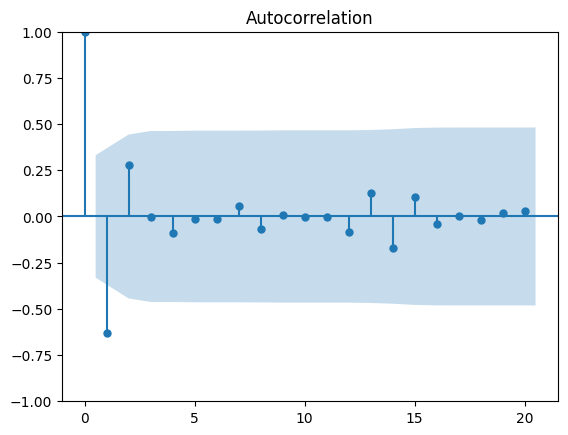

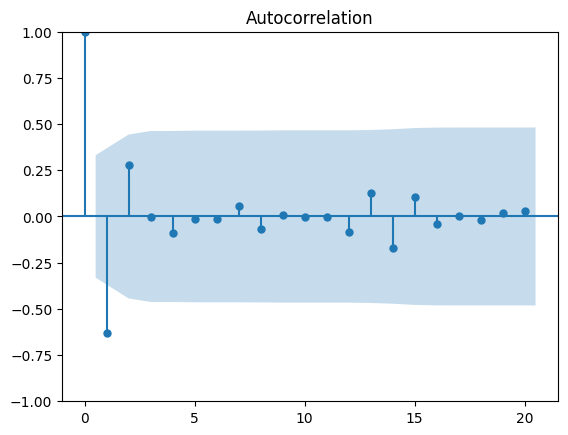

In [43]:
plot_acf(d['diff'].dropna(), lags=20)

Постройте диаграмму PACF для параметра p (для диаграммы не должно быть NaN, а лагов не может быть больше чем половина 50% подаваемого датафрейма\временного ряда: у Вас 35 точек будет, значит не более 17 лагов - Вы поставьте 15):

Рассмотрите диаграмму: 

- параметром p будет то число где PACF резко обрывается (это AR часть): где высокие столбы – и на каком шаге становятся около 0 (точнее попадает в синее поле доверительного интервала в котором может быть истинное значение).

- большим P для SARIMA будет такой же подход, но с подсчетом только сезонных лагов (12, 24…) за пределами дов.интервала

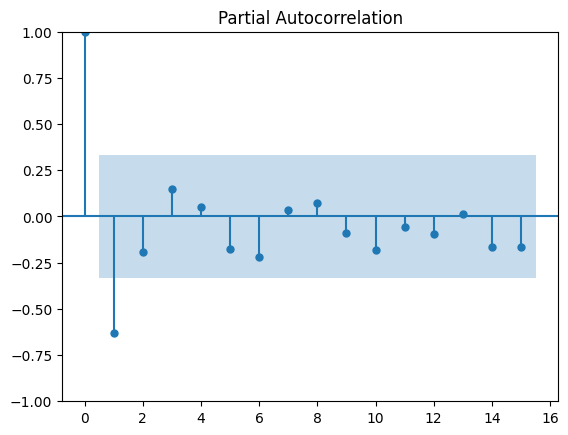

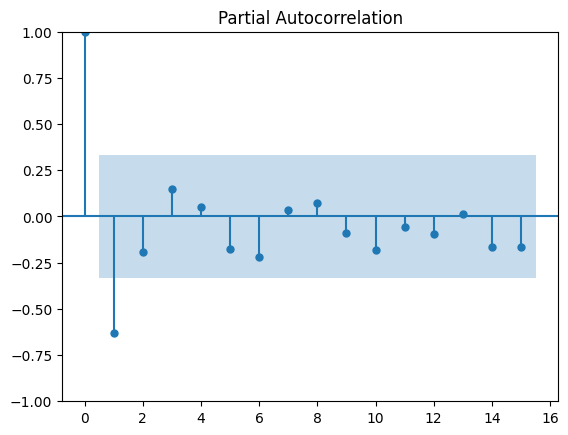

In [44]:
plot_pacf(d['diff'].dropna(), lags=15)

- d и D– колв-во раз дифференцирования для ряда и для сезонности пока не добились стационарности ряда
- q – обрыв ACF (приближение к 0)
- p – обрыв PACF (приближение к 0)
- Q – к-во сезонных лагов выбивающихся за коридор
- P – вылетающие за интервал сезонные лаги.

In [46]:
model = SARIMAX(d['Продажи'], order=(2,1,2), seasonal_order=(0,1,0,12)) # по цифрам расставьте соотв. параметры

In [47]:
result = model.fit()

В сводке .summary() просмотрите сначала на показатели Coef – это насколько весомый вклад лагов в модель. Если они незначимы - значит модель переусложнена или спецификация не очень удалась.

Потом посмотрите  что у Вас с остатками:

- Ljung-Box – если значим то у остатков есть автокорреляция: это плохо.
- Жарко-Бера – если значим, значит остатки не нормальны.
- Гетероскедастичность (непостоянная дисперсия ошибок) – наблюдается или нет (вспомните по лекции)
- Ассиметрия и Эксцесс – если большие, то нет нормальности в распределении остатков.

Если все по остаткам ненормальность и автокорреляции -  они не просто так назывемый «белый шум».

In [48]:
print(result.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             Продажи   No. Observations:                   48
Model:             SARIMAX(2, 1, 2)x(0, 1, [], 12)   Log Likelihood                -314.464
Date:                             Wed, 07 Jan 2026   AIC                            638.928
Time:                                     23:09:14   BIC                            646.705
Sample:                                          0   HQIC                           641.612
                                              - 48                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8568      6.781     -0.126      0.899     -14.147      12.434
ar.L2         -0.0526      

In [49]:
resid = result.resid

<Axes: >

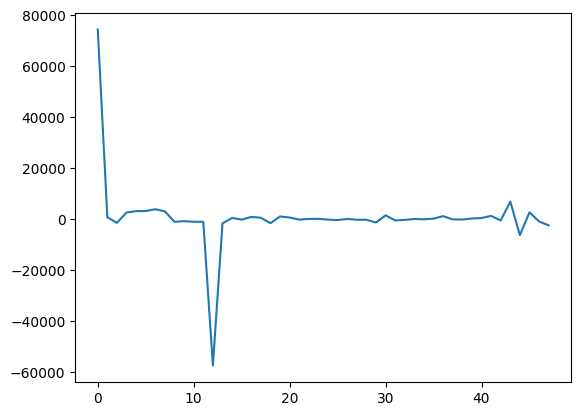

In [50]:
resid.plot()

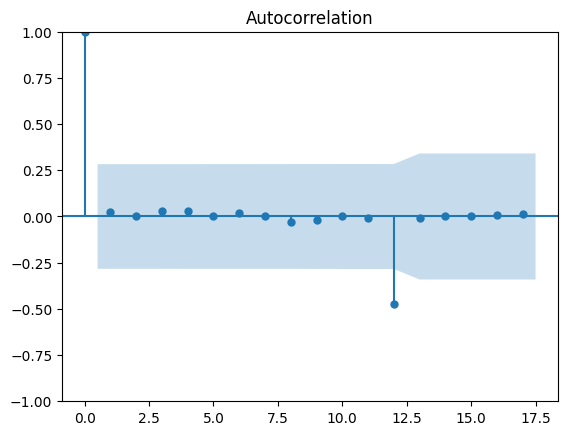

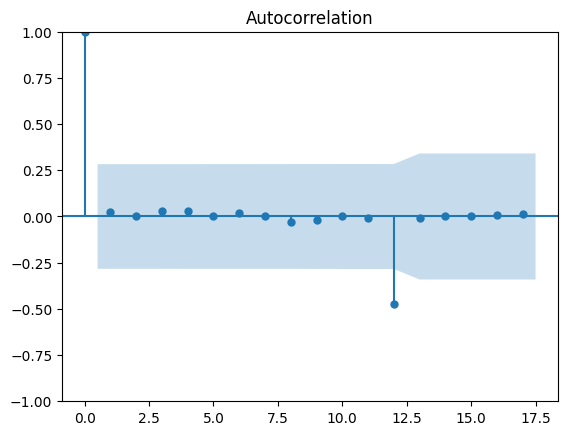

In [51]:
plot_acf(resid)

In [52]:
forecast = result.get_forecast(steps=12)
pm = forecast.predicted_mean
ci = forecast.conf_int()

In [53]:
V = pd.DataFrame({'Факт': d['Продажи'], 'Прогноз': pm, 'НГ': ci.iloc[:, 0], 'ВГ': ci.iloc[:, 1]})

In [54]:
V

,Факт,Прогноз,НГ,ВГ
0,74440.0,NaN,NaN,NaN
1,73344.0,NaN,NaN,NaN
2,72517.0,NaN,NaN,NaN
3,74765.0,NaN,NaN,NaN
4,78176.0,NaN,NaN,NaN
5,81059.0,NaN,NaN,NaN
6,85097.0,NaN,NaN,NaN
7,87902.0,NaN,NaN,NaN
8,86943.0,NaN,NaN,NaN
9,86117.0,NaN,NaN,NaN


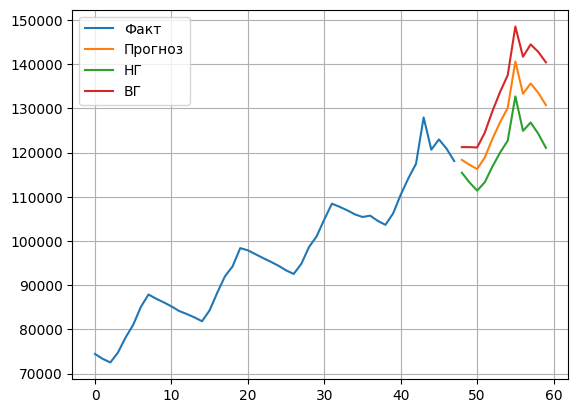

In [56]:
ax = V.plot(grid=True)